# Load packages and libraries

In [1]:
.libPaths()
.libPaths(new = c("/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/lib/R/library"))
.libPaths()
# sessionInfo()

Sys.setenv(RETICULATE_PYTHON="/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/bin/python")
library(reticulate)
reticulate::use_python("/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/bin/python")
reticulate::use_condaenv("/home/manuel.tardaguila/conda_envs/multiome_QC_DEF")
reticulate::py_module_available(module='leidenalg')
reticulate::import('leidenalg')
suppressMessages(library("optparse"))
suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(Matrix))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))
suppressMessages(library(ggplot2))
suppressMessages(library(scDblFinder))
suppressMessages(library("tidyr"))
suppressMessages(library("tibble"))
suppressMessages(library("biovizBase"))
suppressMessages(library("patchwork"))
suppressMessages(library(glmGamPoi))
suppressMessages(library(SeuratData))
suppressMessages(library(SeuratDisk))
library(svglite)
library(RColorBrewer)




[1] "/home/manuel.tardaguila/R/x86_64-conda-linux-gnu-library/4.3"    
[2] "/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/lib/R/library"

[1] "/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/lib/R/library"

[1] TRUE

Module(leidenalg)

Warning message:
“package ‘optparse’ was built under R version 4.3.3”
Warning message:
“package ‘Seurat’ was built under R version 4.3.2”
Warning message:
“package ‘Signac’ was built under R version 4.3.2”
Warning message:
“package ‘ensembldb’ was built under R version 4.3.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.2”
Warning message:
“package ‘IRanges’ was built under R version 4.3.2”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicFeatures’ was built under R version 4.3.2”
Warning message:
“package ‘AnnotationDbi’ was built under R version 4.3.2”
Warning message:
“package ‘Biobase’ was built under R version 4.3.2”
Warning message:
“package ‘AnnotationFilter’ was built under R version 4.3.2”
Warning message:
"package 'scDblFinder' was built under R ver

In [2]:
suppressMessages(library(svglite))
suppressMessages(library(RColorBrewer))
suppressMessages(library(forcats))
suppressMessages(library(cowplot))
suppressMessages(library(plyr))

In [3]:
#AvailableData()

# Read objects merged_unprocessed_db_filt_clustered_QCed

In [4]:
setwd("/scratch/manuel.tardaguila/2026_Ditadi_test/processing_outputs/")



In [5]:
adata<-readRDS(file="merged_unprocessed_db_filt_clustered_QCed_reclustered.rds")

In [6]:
adata

An object of class Seurat 
100059 features across 19792 samples within 3 assays 
Active assay: SCT (27285 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, RNA_raw
 2 dimensional reductions calculated: pca, umap.rna

# General plots

In [10]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2026_Ditadi_test/PRE_RPCA/graphs/"

if(file.exists(path_graphs)){
    
}else{

    dir.create(path_graphs, recursive=TRUE)
}

## UMAP by sample

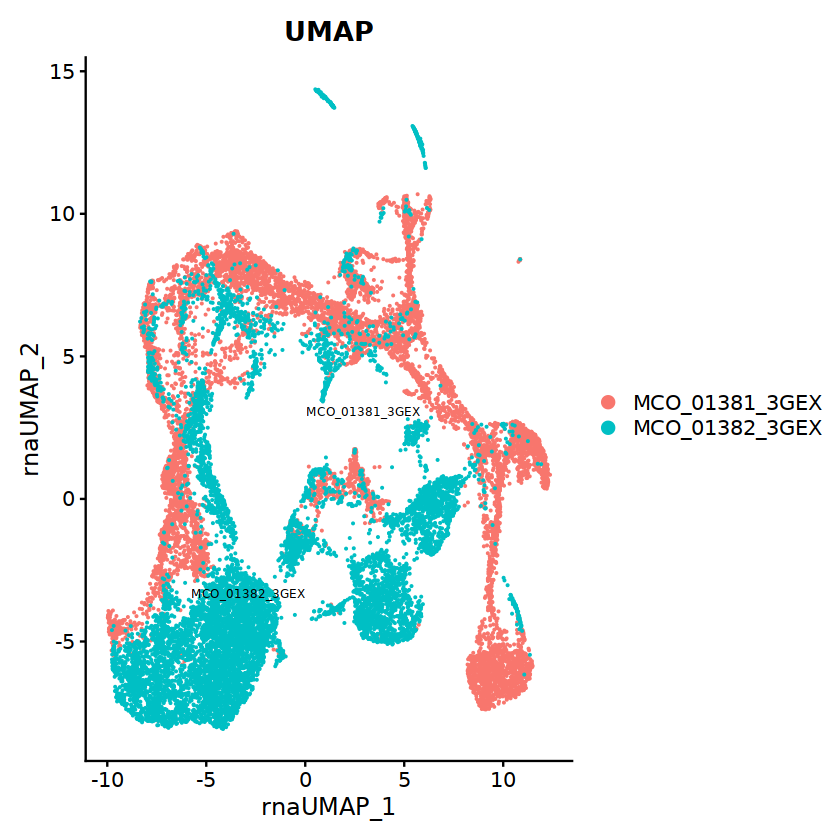

In [11]:
p3 <- DimPlot(adata, reduction = "umap.rna", group.by = "orig.ident", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")
p3

In [12]:
## Graph UMAP by CellTypist_label_filtered

setwd(path_graphs)
png(file='UMAP_by_sample.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

## UMAP by Seurat clusters

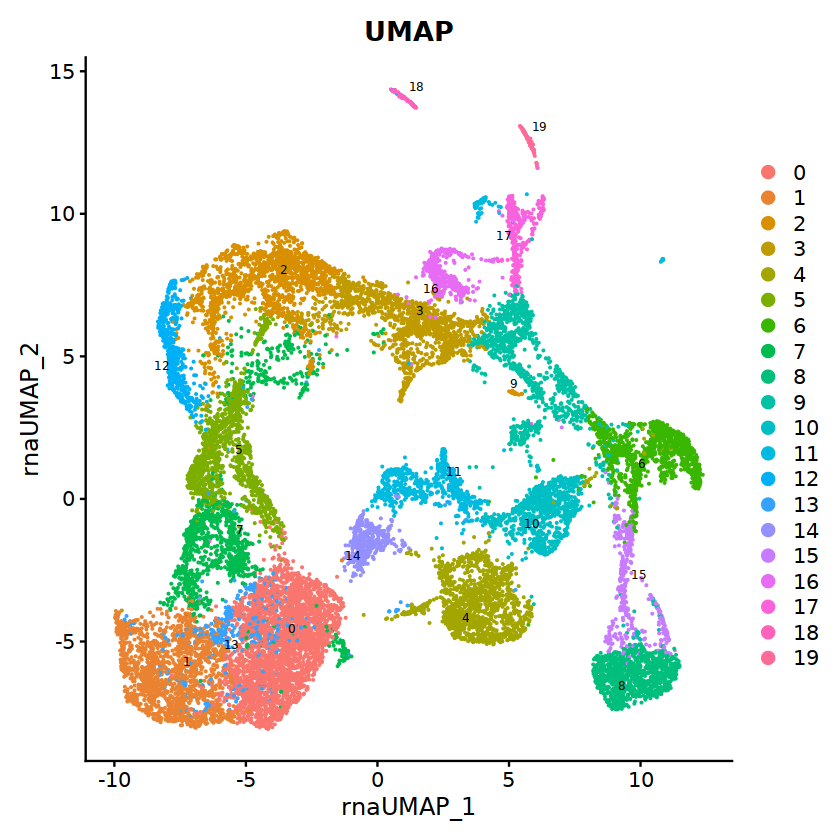

In [13]:
p3 <- DimPlot(adata, reduction = "umap.rna", group.by = "seurat_clusters", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")
p3

In [14]:
## Graph UMAP by CellTypist_label_filtered

setwd(path_graphs)
png(file='UMAP_by_seurat_clusters.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

## Graph UMAP by marker genes

In [15]:
DefaultAssay(adata) <- 'SCT'

genes<-Features(adata)

str(genes)

 chr [1:27285] "AL627309.1" "AL627309.3" "AL627309.5" "AP006222.2" ...


In [16]:
genes[grep("GZM", genes)]

[1] "GZMA" "GZMB" "GZMM"

In [17]:
genes[grep("IFNG", genes)]

[1] "IFNGR1"   "IFNG-AS1" "IFNGR2"

In [18]:
DefaultAssay(adata) <- 'SCT'

In [19]:
phESC <- FeaturePlot(adata, features = c('SOX2','SOX4','POU5F1'),
                  reduction = 'umap.rna', 
                  cols = c("lightgrey","darkgreen"), ncol = 3)

# Add the title using plot_annotation
phESC <- phESC + plot_annotation(
  title = 'Markers of hESCs',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

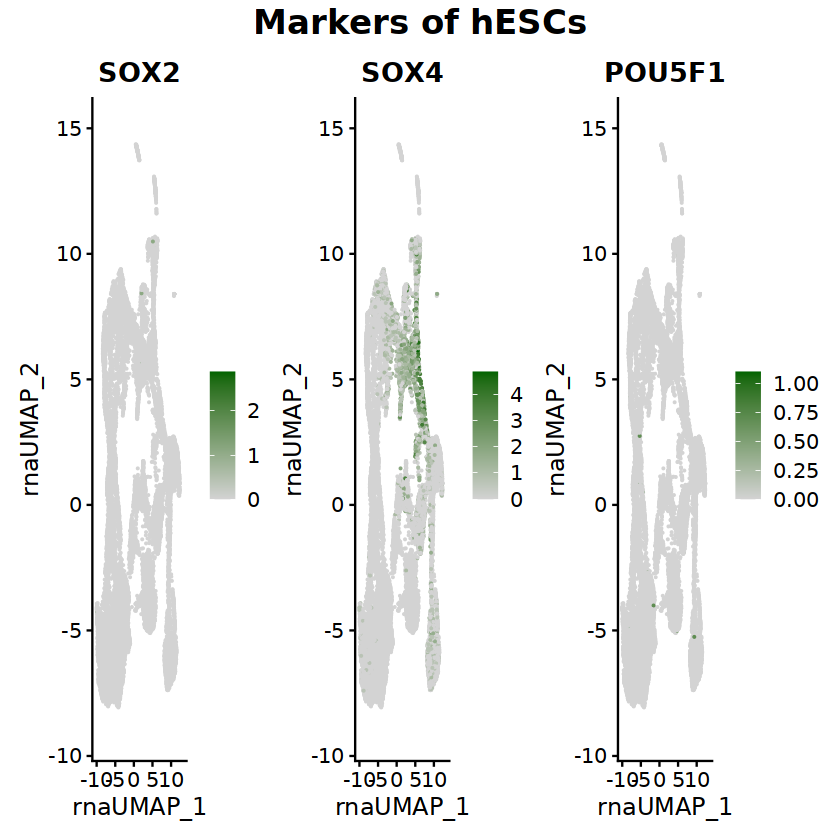

In [20]:
phESC

In [21]:
setwd(path_graphs)
png(file='UMAP_marker_genes_hESC.png', width =1000, height = 250)
phESC
dev.off()

png 
  2

In [22]:
pEndoderm <- FeaturePlot(adata, features = c("HNF4A",'APOA1','EPCAM'),
                  reduction = 'umap.rna', 
                  cols = c("lightgrey","darkgreen"), ncol = 3)

# Add the title using plot_annotation
pEndoderm <- pEndoderm + plot_annotation(
  title = 'Markers of Endoderm',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

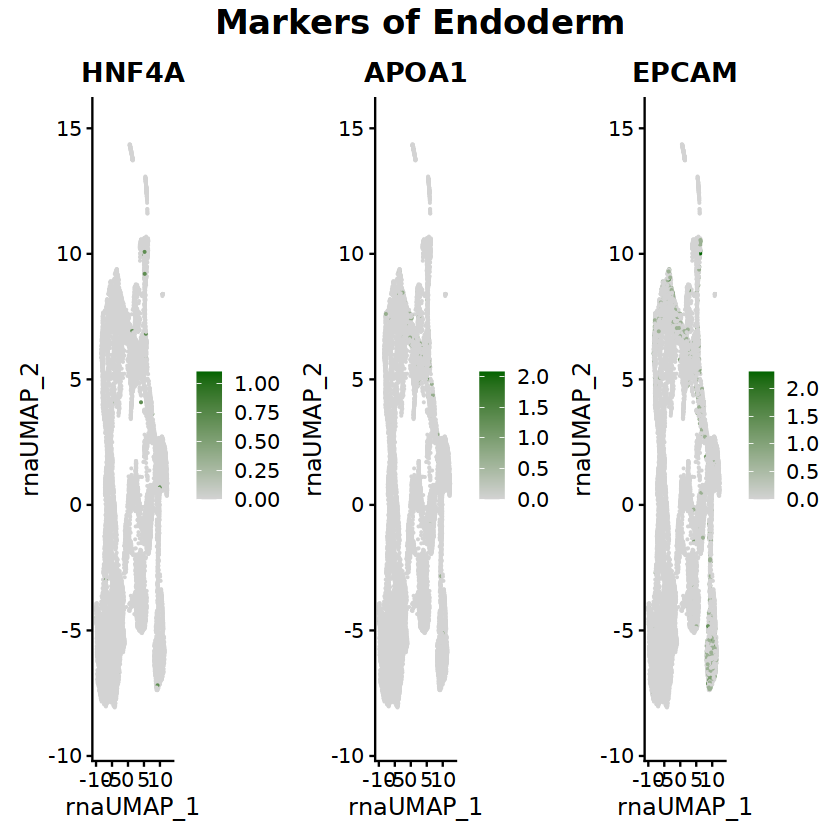

In [23]:
pEndoderm

In [24]:
setwd(path_graphs)
png(file='UMAP_marker_genes_Endoderm.png', width =1000, height = 250)
pEndoderm
dev.off()

png 
  2

In [25]:
pHSC <- FeaturePlot(adata, features = c("KDR",'CDH5','CD34'),
                  reduction = 'umap.rna', 
                  cols = c("lightgrey","darkgreen"), ncol = 3)

# Add the title using plot_annotation
pHSC <- pHSC + plot_annotation(
  title = 'Markers of HSCs',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

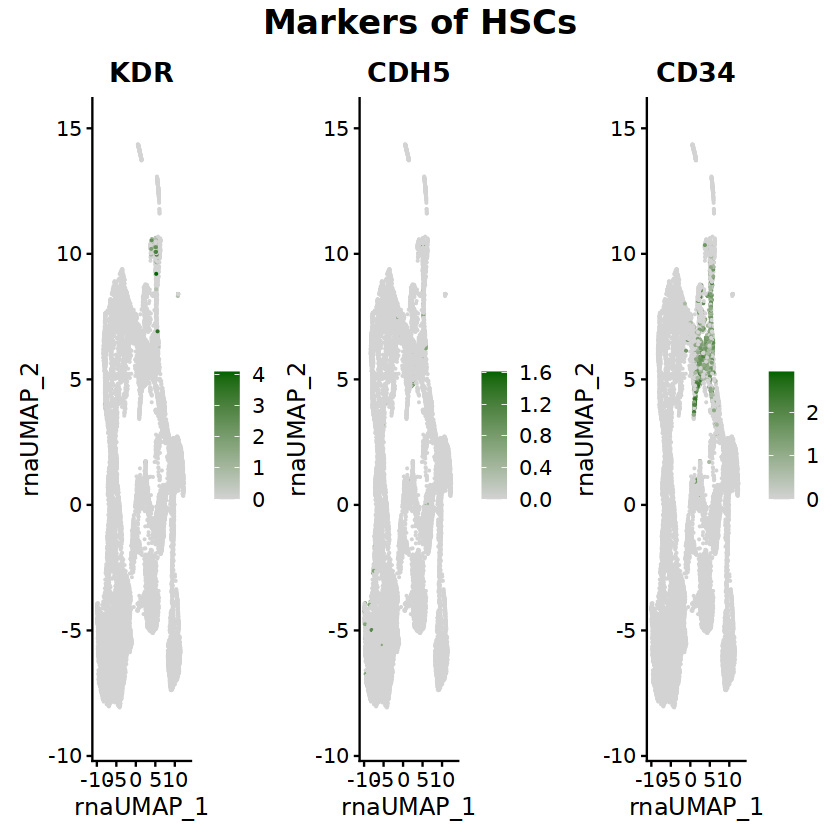

In [26]:
pHSC

In [27]:
setwd(path_graphs)
png(file='UMAP_marker_genes_HSCs.png', width =1000, height = 250)
pHSC
dev.off()

png 
  2

In [28]:
pRBC <- FeaturePlot(adata, features = c('GYPA','HBA2','HBZ'),
                    reduction = 'umap.rna', 
                    cols = c("lightgrey","darkgreen"), ncol = 3)

# Add the title using plot_annotation
pRBC <- pRBC + plot_annotation(
  title = 'Markers of erythroid lineage',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

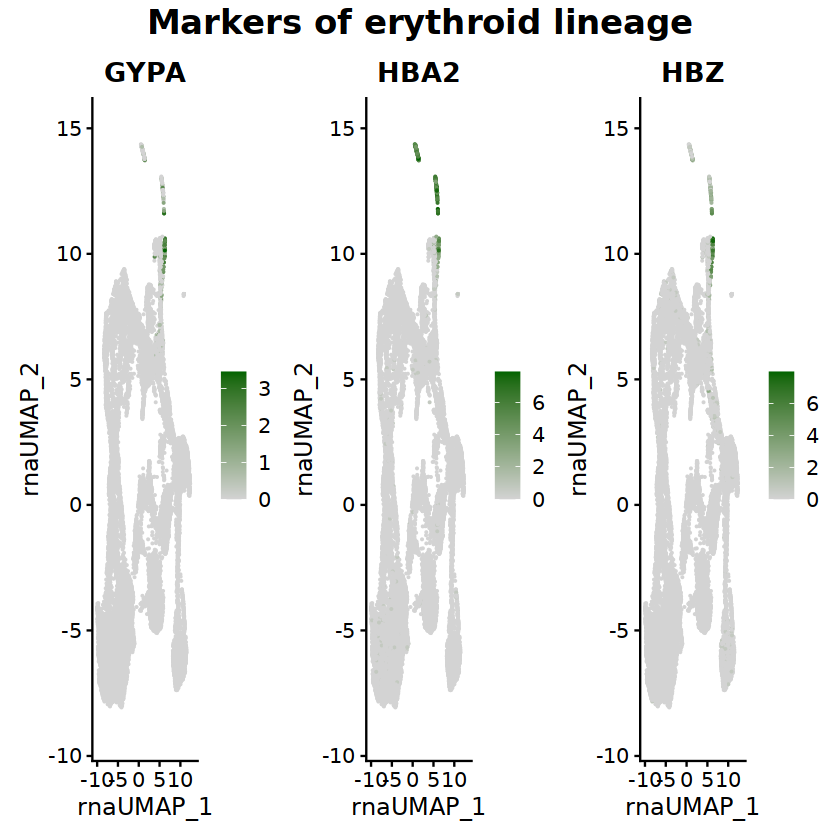

In [29]:
pRBC

In [30]:
setwd(path_graphs)
png(file='UMAP_marker_genes_erythroid_lineage.png', width =1000, height = 250)
pRBC
dev.off()

png 
  2

In [31]:
pMK <- FeaturePlot(adata, features = c('ITGA2B','GP1BA', 'GP1BB'),
                    reduction = 'umap.rna', 
                    cols = c("lightgrey","darkgreen"), ncol = 3)

# Add the title using plot_annotation
pMK <- pMK + plot_annotation(
  title = 'Markers of megakaryocyte lineage',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

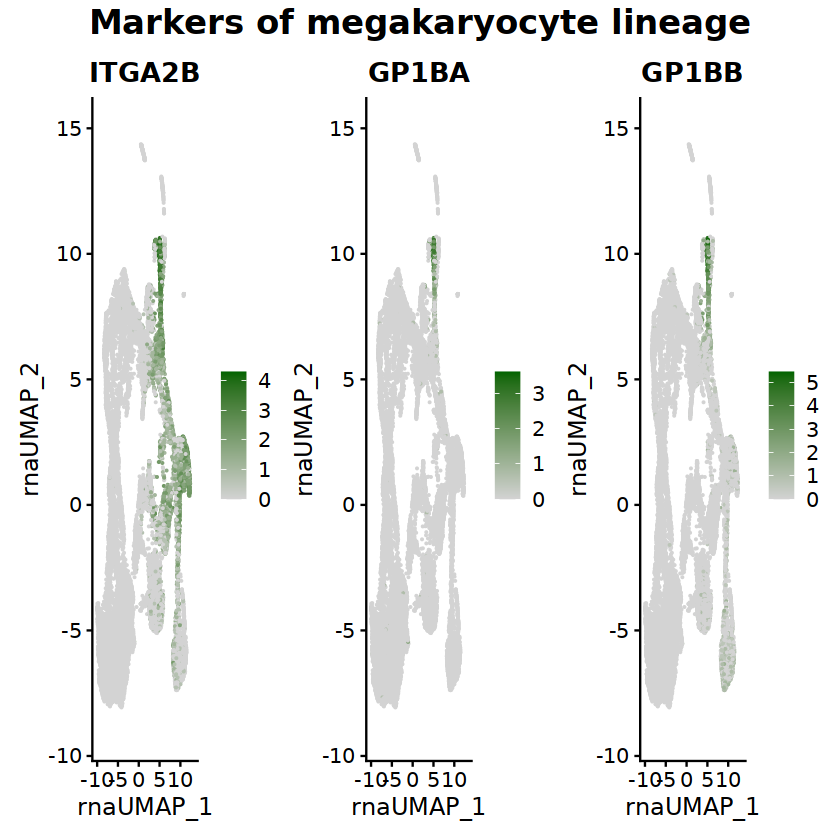

In [32]:
pMK

In [33]:
setwd(path_graphs)
png(file='UMAP_marker_genes_megakaryocyte_lineage.png', width =1000, height = 250)
pMK
dev.off()

png 
  2

In [34]:
pMAST <- FeaturePlot(adata, features = c('CPA3','CD33','PTPRC','TPSB2'),
                    reduction = 'umap.rna', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

# Add the title using plot_annotation
pMAST <- pMAST + plot_annotation(
  title = 'Markers of Mast cells',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

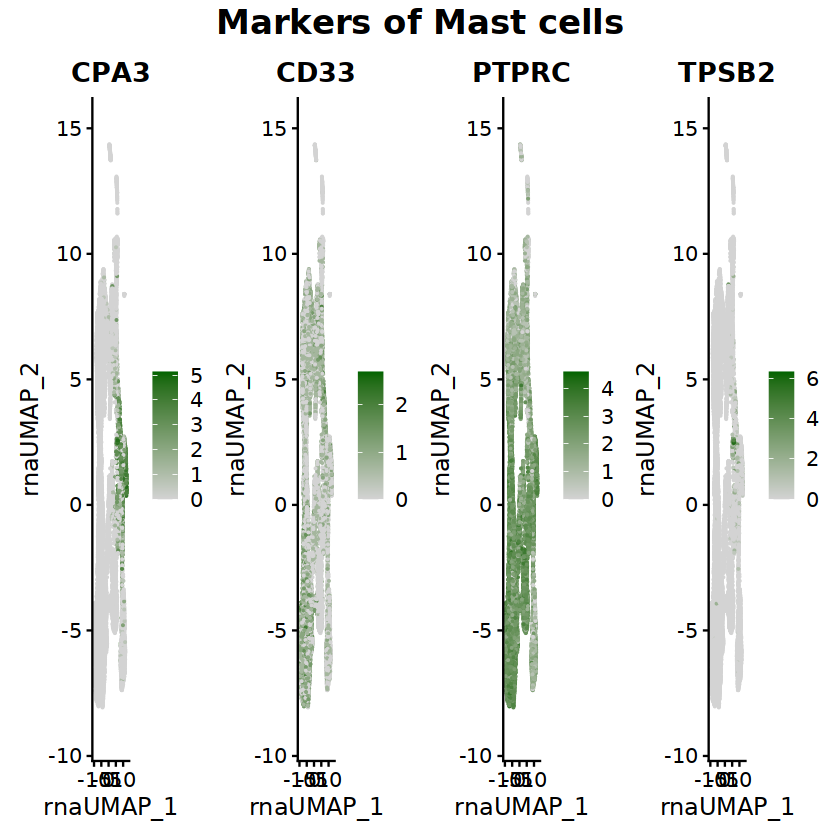

In [35]:
pMAST

In [36]:
setwd(path_graphs)
png(file='UMAP_marker_genes_Mast_cells.png', width =1000, height = 250)
pMAST
dev.off()

png 
  2

In [37]:
pPrecursorMonocyteDC <- FeaturePlot(adata, features = c('CD33','PTPRC','CD1C','HLA-DRA'),
                    reduction = 'umap.rna', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

# Add the title using plot_annotation
pPrecursorMonocyteDC <- pPrecursorMonocyteDC + plot_annotation(
  title = 'Markers of precursor of monocytes and DCs',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

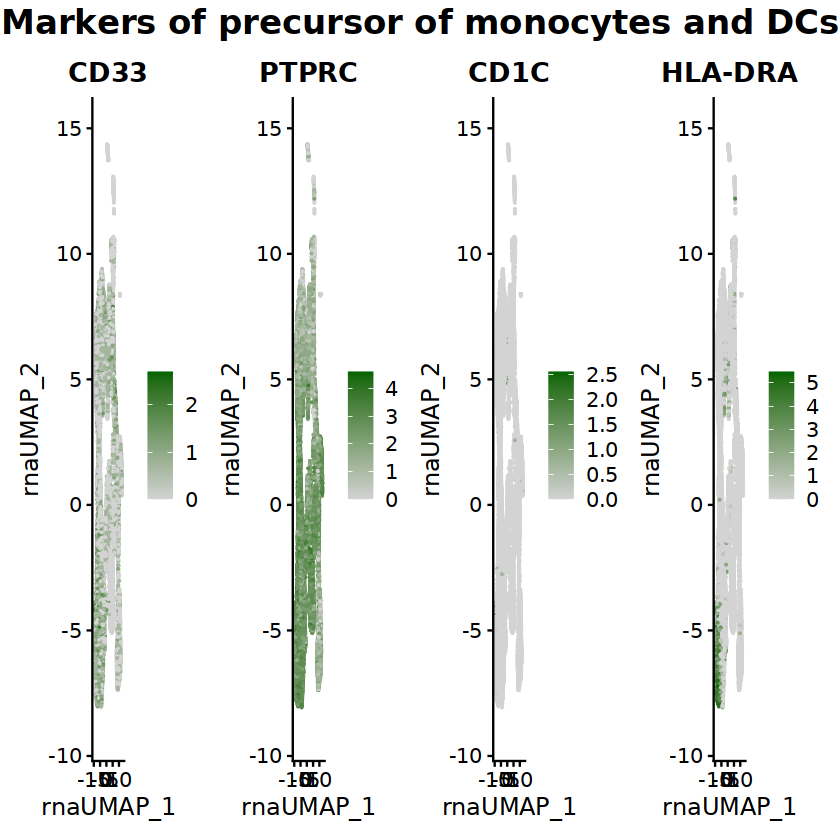

In [38]:
pPrecursorMonocyteDC

In [39]:
setwd(path_graphs)
png(file='UMAP_marker_genes_precursor_of_monocytes_and_DCs.png', width =1000, height = 250)
pPrecursorMonocyteDC
dev.off()

png 
  2

In [40]:
pPrecursorNF_mye <- FeaturePlot(adata, features = c('CD33','PTPRC','MPO','S100A9'),
                    reduction = 'umap.rna', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

# Add the title using plot_annotation
pPrecursorNF_mye <- pPrecursorNF_mye + plot_annotation(
  title = 'Markers of precursor of Neutrophils and myeloid cells',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

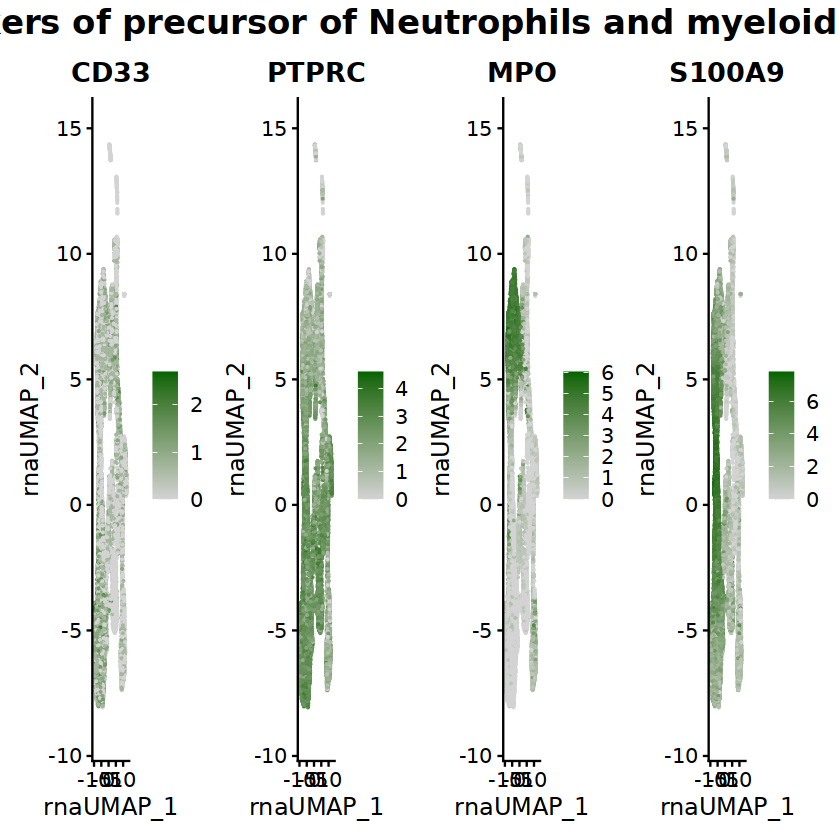

In [41]:
pPrecursorNF_mye

In [42]:
setwd(path_graphs)
png(file='UMAP_marker_genes_precursor_of_Neutrophils_and_myeloid_cells.png', width =1000, height = 250)
pPrecursorNF_mye
dev.off()

png 
  2

In [43]:
pMono <- FeaturePlot(adata, features = c('PTPRC','HLA-DRA','S100A9','CD14'),
                    reduction = 'umap.rna', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

# Add the title using plot_annotation
pMono <- pMono + plot_annotation(
  title = 'Markers of precursor of monocytes',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

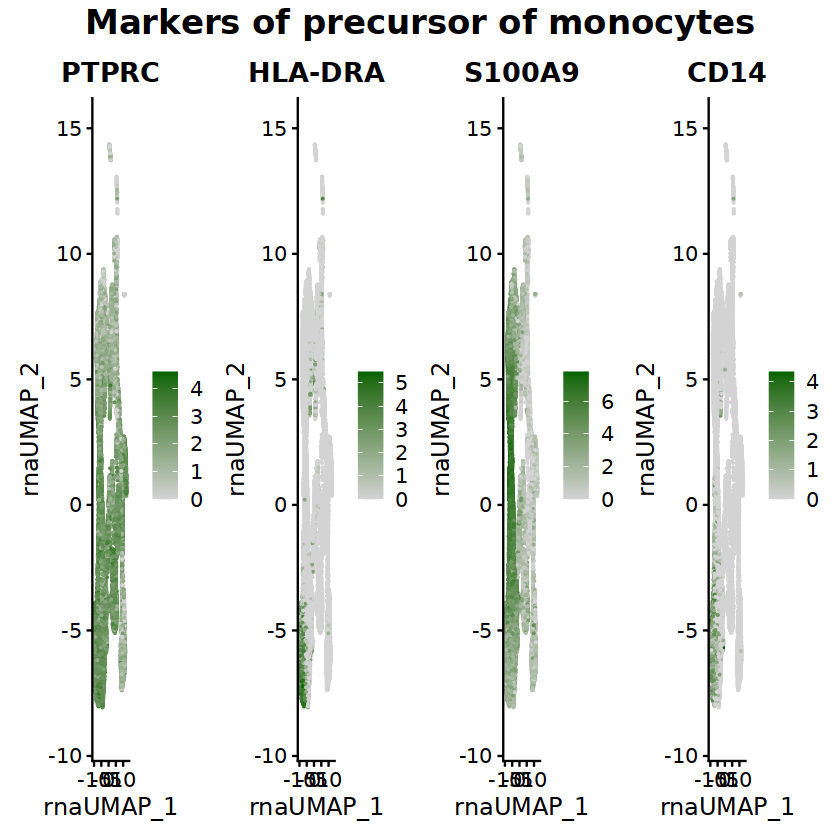

In [44]:
pMono

In [45]:
setwd(path_graphs)
png(file='UMAP_marker_genes_Monocytes.png', width =1000, height = 250)
pMono
dev.off()

png 
  2

In [46]:
pNK <- FeaturePlot(adata, features = c('NCAM1','NKG7','FCGR3A','KLRD1','GNLY'),
                    reduction = 'umap.rna', 
                    cols = c("lightgrey","darkgreen"), ncol = 5)

# Add the title using plot_annotation
pNK <- pNK + plot_annotation(
  title = 'Markers of precursor of NK cells',
  theme = theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
  )
)

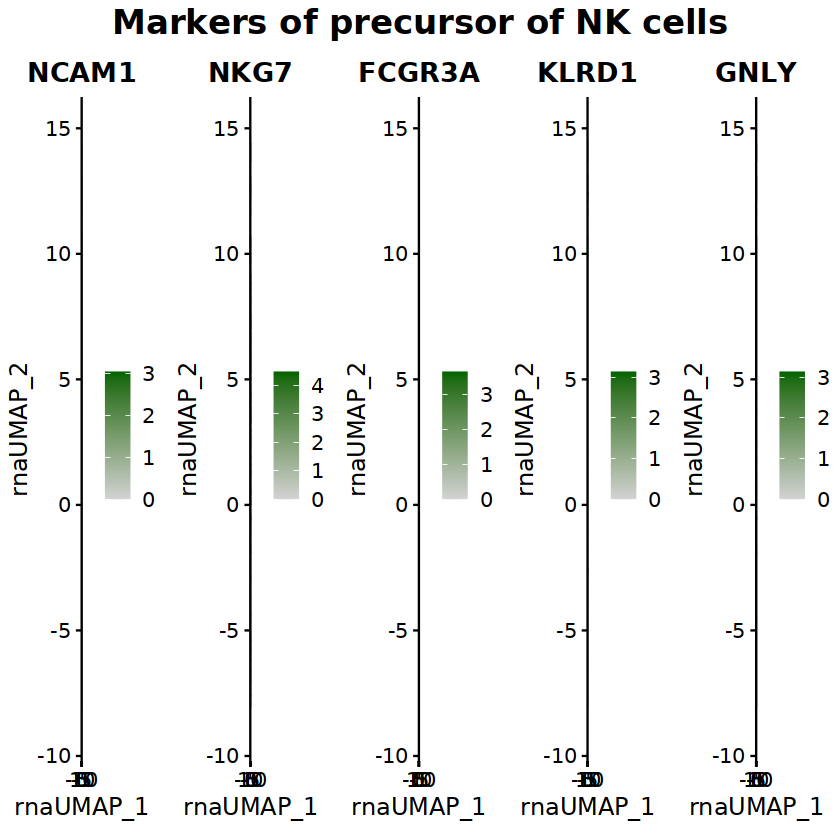

In [47]:
pNK

In [48]:
setwd(path_graphs)
png(file='UMAP_marker_genes_NK_cells.png', width =1000, height = 250)
pNK
dev.off()

png 
  2

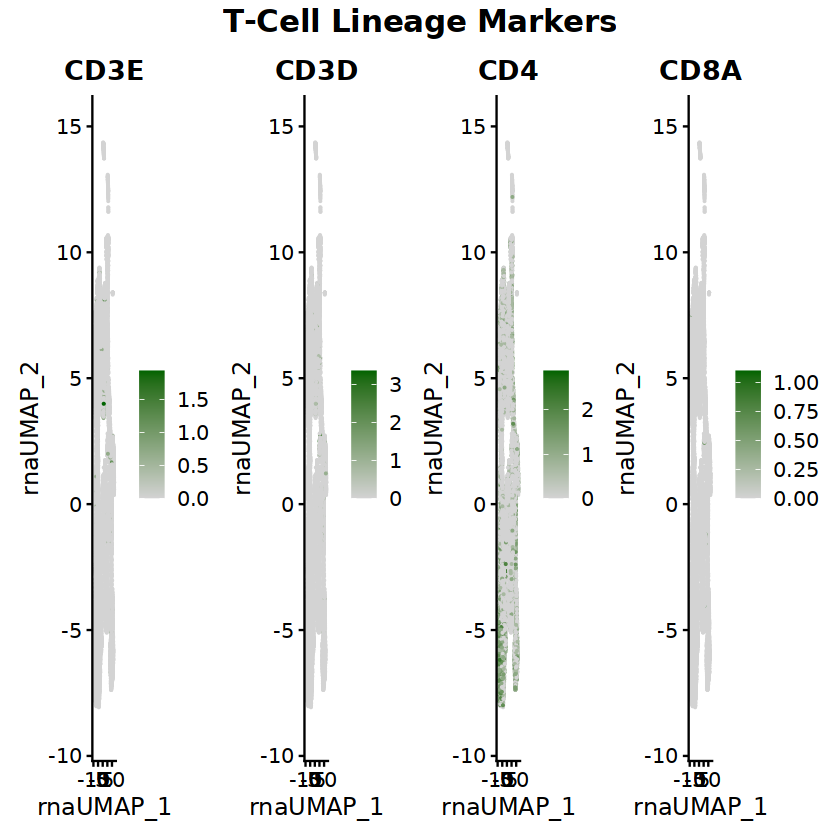

In [49]:
# T-Cell Markers
pT <- FeaturePlot(adata, features = c('CD3E', 'CD3D', 'CD4', 'CD8A'),
                  reduction = 'umap.rna', cols = c("lightgrey", "darkgreen"), ncol = 4) +
      plot_annotation(title = 'T-Cell Lineage Markers', 
                      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5)))


pT

In [50]:
setwd(path_graphs)
png(file='UMAP_marker_genes_T_cells.png', width =1000, height = 250)
pT
dev.off()

png 
  2

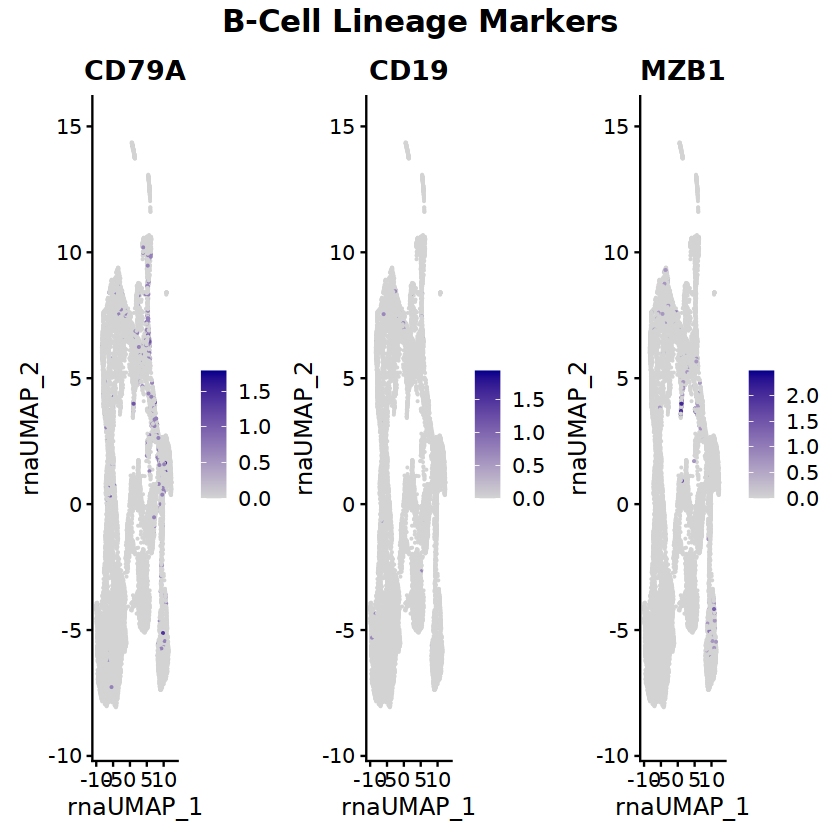

In [51]:
pB <- FeaturePlot(adata, features = c('CD79A', 'CD19', 'MZB1'),
                  reduction = 'umap.rna', cols = c("lightgrey", "darkblue"), ncol = 3) +
      plot_annotation(title = 'B-Cell Lineage Markers', 
                      theme = theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5)))

pB

In [52]:
setwd(path_graphs)
png(file='UMAP_marker_genes_B_cells.png', width =1000, height = 250)
pB
dev.off()

png 
  2